In [3]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

In [4]:
def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            # Compare predictions with ground truth labels
            # and accumulate number of correct predictions.
            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # The number of channels in the convolutional layers is progressively increased (32 → 64 → 128)
        # to enable a stronger hierarchical feature representation.
        #
        # In tasks such as traffic sign recognition (GTSRB), class differences are often subtle and
        # rely on fine-grained visual details (symbols, numbers, internal shapes, and small structural variations).
        #
        # By increasing the number of filters to 128 in the final convolutional layer,
        # the model gains higher representational capacity, allowing it to capture a more diverse set
        # of high-level features, especially after spatial resolution reduction.
        #
        # This is particularly important because, as the feature map size decreases (e.g., 8x8),
        # spatial detail is lost, and this must be compensated by increasing channel depth
        # in order to preserve and combine relevant information for classification.

        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = torch.nn.BatchNorm2d(128)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.dropout = torch.nn.Dropout(p=0.5)

        # GAP -> 128 canais
        self.fc1 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # input = (bs, 3, 32, 32)

        x = self.conv1(x)       # -> (bs, 32, 32, 32)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)       # -> (bs, 64, 32, 32)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.maxpool1(x)    # -> (bs, 64, 16, 16)

        x = self.conv3(x)       # -> (bs, 128, 16, 16)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)       # -> (bs, 128, 16, 16)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.maxpool2(x)    # -> (bs, 128, 8, 8)

        # Global Average Pooling
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 128)

        x = self.dropout(x)

        x = self.fc1(x)

        return x

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526' ### CHANGE THIS TO YOUR OWN PATH

PATH_TEST_SET = f'{BASE_PATH}/test_images'       ### TEST SET PATH

BATCH_SIZE = 32

RUNS = 3                                         ### Number of runs for each model to compute mean test accuracy

cuda:0


In [6]:
transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

test_set = torchvision.datasets.ImageFolder(
    root=PATH_TEST_SET,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [7]:
""" models = []
acc = []

for i in range(RUNS):

    reload = torch.load(f'model_weights/baseline_aug_I_{i}.pt')

    model = Conv_II(len(test_set.classes))
    model.load_state_dict(reload['model'])

    model.to(device)

    models.append(model)
    acc.append(evaluate(models[i], test_loader)) """

" models = []\nacc = []\n\nfor i in range(RUNS):\n\n    reload = torch.load(f'model_weights/baseline_aug_I_{i}.pt')\n\n    model = Conv_II(len(test_set.classes))\n    model.load_state_dict(reload['model'])\n\n    model.to(device)\n\n    models.append(model)\n    acc.append(evaluate(models[i], test_loader)) "

In [8]:
models = []
acc = []

aug_files = [
    "baseline_aug_I",
    "dynamic_colorJitter_aug_I",
    "dynamic_randomAffine_aug_I",
    "dynamic_gaussianBlur_aug_I",
    "dynamic_randomErasing_aug_I",
    "dynamic_all_aug_I",
    "static_colorJitter_aug_I",
    "static_randomAffine_aug_I",
    "static_gaussianBlur_aug_I",
    "static_randomErasing_aug_I",
    "static_all_aug_I"
]

for aug_name in aug_files:

    for i in range(RUNS):

        reload = torch.load(
            f"model_weights/{aug_name}_{i}.pt"
        )

        model = Conv_II(len(test_set.classes))

        model.load_state_dict(reload['model'])

        model.to(device)
        model.eval()

        models.append(model)

        acc.append(evaluate(model, test_loader))

Accuracy - mean: 0.9890856309370561 max: 0.9939825534820557 min: 0.9810767769813538


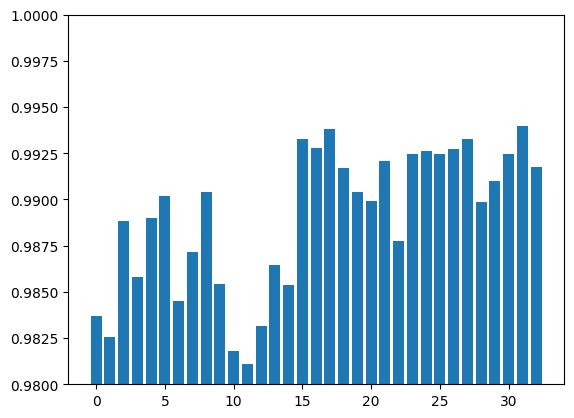

In [9]:
index = [i for i in range(len(acc))]

plt.bar(index, acc)

print(
    'Accuracy - mean:', np.mean(acc),
    'max:', np.max(acc),
    'min:', np.min(acc)
)

plt.ylim(0.98, 1.0)

plt.show()

In [10]:
def get_labels_logits_and_preds(models):

    num_models = len(models)

    for model in models:
        model.eval()

    with torch.no_grad():

        logits = [[] for _ in range(num_models)]
        labels = []

        for images, labs in test_loader:

            images = images.to(device)

            labels.extend(labs.tolist())

            for i in range(num_models):

                output = models[i](images).cpu()

                logits[i].extend(output)

    return labels, logits

SOFTVOTING

In [11]:
def get_preds_from_soft_voting(logits):

    predictions = []

    num_samples = len(logits[0])

    for i in range(num_samples):

        probs = torch.softmax(logits[0][i], dim=0).clone()

        for m in range(1, len(logits)):

            probs = probs + torch.softmax(logits[m][i], dim=0)

        probs = probs / len(logits)

        pred = torch.argmax(probs).item()

        predictions.append(pred)

    return predictions

In [12]:
labels, logits = get_labels_logits_and_preds(models)

predictions = get_preds_from_soft_voting(logits)

print(predictions[3990:4000])
print(labels[3990:4000])

[8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
[8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


In [13]:
# accuracy of soft-voting ensemble
correct_soft = sum(1 for y, p in zip(labels, predictions) if y == p)
acc_soft = correct_soft / len(labels)

print("Soft-voting ensemble accuracy:", acc_soft)

Soft-voting ensemble accuracy: 0.9960411718131433


HARDVOTING

In [14]:
preds = [[] for _ in range(len(labels))]

for index in range(len(labels)):

    preds[index] = [
        np.argmax(logits[m][index].cpu().numpy())
        for m in range(len(logits))
    ]

print(preds[4000])

[np.int64(5), np.int64(3), np.int64(8), np.int64(5), np.int64(5), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(3), np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8)]


In [15]:
import collections 

def get_stats(labels, class_preds):

    all_correct = 0
    all_incorrect = 0
    maj_vote = 0
    maj_wrong = 0
    tie = 0
    count = 0

    for k in range(len(labels)):

        counter = collections.Counter(class_preds[k])
        if len(counter) == 1:
            if counter.most_common(1)[0][0] == labels[k]:
                all_correct += 1
            else:
                all_incorrect += 1
        else:
            aux = counter.most_common(2)
            if aux[0][1] > aux[1][1] and aux[0][0] == labels[k]:
                maj_vote += 1
            if aux[0][1] > aux[1][1] and aux[0][0] != labels[k]:
                maj_wrong += 1
            elif aux[0][1] == aux[1][1]:
                tie += 1

        count += 1 
        
    return [count, all_correct, all_incorrect, maj_vote, tie, maj_wrong]
    
    
res = get_stats(labels, preds)
print('total: ', res[0])
print('All correct: ', res[1])
print('All incorrect: ', res[2])
print('Majority correct: ', res[3])
print('Tie Vote: ', res[4])
print('Majority Wrong: ', res[5])
print('Percentage right (all correct + majority correct): ', (res[1]+res[3])/res[0])

total:  12630
All correct:  12024
All incorrect:  1
Majority correct:  552
Tie Vote:  2
Majority Wrong:  51
Percentage right (all correct + majority correct):  0.9957244655581948


Ensemble FIXES errors:

Index: 83
True label: 1 (00001)
Per-model predictions: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(13), np.int64(1), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
Soft-vote prediction: 1 (00001)


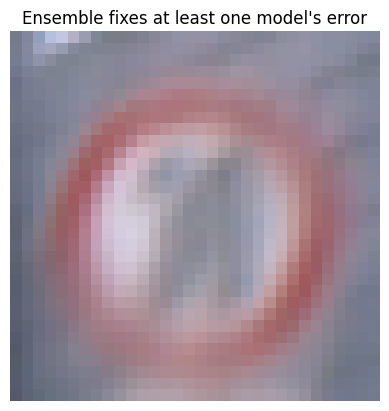


Ensemble AMPLIFIES errors:

Index: 1666
True label: 3 (00003)
Per-model predictions: [np.int64(5), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(5), np.int64(5), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(3), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(3), np.int64(5)]
Soft-vote prediction: 5 (00005)


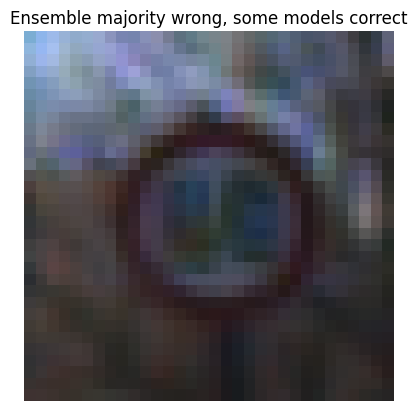

In [16]:
import matplotlib.pyplot as plt

def show_example(idx, title):
    img, _ = test_set[idx]  # transformed image
    # assumes transform produced floats in [0, 1]
    img_np = img.permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(title)
    plt.show()

def format_case(idx, labels, preds, predictions):
    true = labels[idx]
    hard_votes = preds[idx]
    soft_pred = predictions[idx]
    return (
        f"Index: {idx}\n"
        f"True label: {true} ({test_set.classes[true]})\n"
        f"Per-model predictions: {hard_votes}\n"
        f"Soft-vote prediction: {soft_pred} ({test_set.classes[soft_pred]})"
    )

# case where at least one model is wrong, but ensemble (soft) is correct
fix_idx = None
for i in range(len(labels)):
    if labels[i] == predictions[i]:  # ensemble correct
        if any(p != labels[i] for p in preds[i]):  # at least one model wrong
            fix_idx = i
            break

if fix_idx is not None:
    print("Ensemble FIXES errors:\n")
    print(format_case(fix_idx, labels, preds, predictions))
    show_example(fix_idx, "Ensemble fixes at least one model's error")
else:
    print("No example found where ensemble fixes an individual error.")

# case where majority (hard) is wrong, but at least one model is correct
worsen_idx = None
for i in range(len(labels)):
    true = labels[i]
    hard_vote = max(set(preds[i]), key=preds[i].count)  # majority class
    if hard_vote != true and any(p == true for p in preds[i]):
        worsen_idx = i
        break

if worsen_idx is not None:
    print("\nEnsemble AMPLIFIES errors:\n")
    print(format_case(worsen_idx, labels, preds, predictions))
    show_example(worsen_idx, "Ensemble majority wrong, some models correct")
else:
    print("No example found where ensemble amplifies an error.")

WEIGHTED SOFT-VOTING

In [79]:
acc_np = np.array(acc)

temperature = 1000

weights = np.exp(temperature * (acc_np - acc_np.max()))
weights = weights / weights.sum()

print(weights)
print(weights.sum())

[6.93182105e-06 2.28794716e-06 1.19109223e-03 5.87859421e-05
 1.39548255e-03 4.57617188e-03 1.53008848e-05 2.25855369e-04
 5.80307137e-03 3.95675246e-05 1.03657964e-06 5.08288209e-07
 3.98253507e-06 1.10755083e-04 3.65563069e-05 1.00357724e-01
 6.24079096e-02 1.74688543e-01 2.05986274e-02 5.80307137e-03
 3.60866647e-03 3.06036259e-02 3.93137108e-04 4.54681711e-02
 5.32672919e-02 4.54681711e-02 5.76584641e-02 1.00357724e-01
 3.33403518e-03 1.01011665e-02 4.54681711e-02 2.04652736e-01
 2.22953784e-02]
1.0


In [80]:
def get_preds_from_weighted_soft_voting(logits, weights):

    predictions = []

    num_samples = len(logits[0])

    for i in range(num_samples):

        probs = (
            weights[0] *
            torch.softmax(logits[0][i], dim=0)
        )

        for m in range(1, len(logits)):

            probs += (
                weights[m] *
                torch.softmax(logits[m][i], dim=0)
            )

        pred = torch.argmax(probs).item()

        predictions.append(pred)

    return predictions

In [81]:
weighted_predictions = get_preds_from_weighted_soft_voting(
    logits,
    weights
)

In [82]:
correct_weighted = sum(
    1
    for y, p in zip(labels, weighted_predictions)
    if y == p
)

acc_weighted = correct_weighted / len(labels)

print(
    "Weighted Soft Voting accuracy:",
    acc_weighted
)

Weighted Soft Voting accuracy: 0.9961995249406176


Final Results

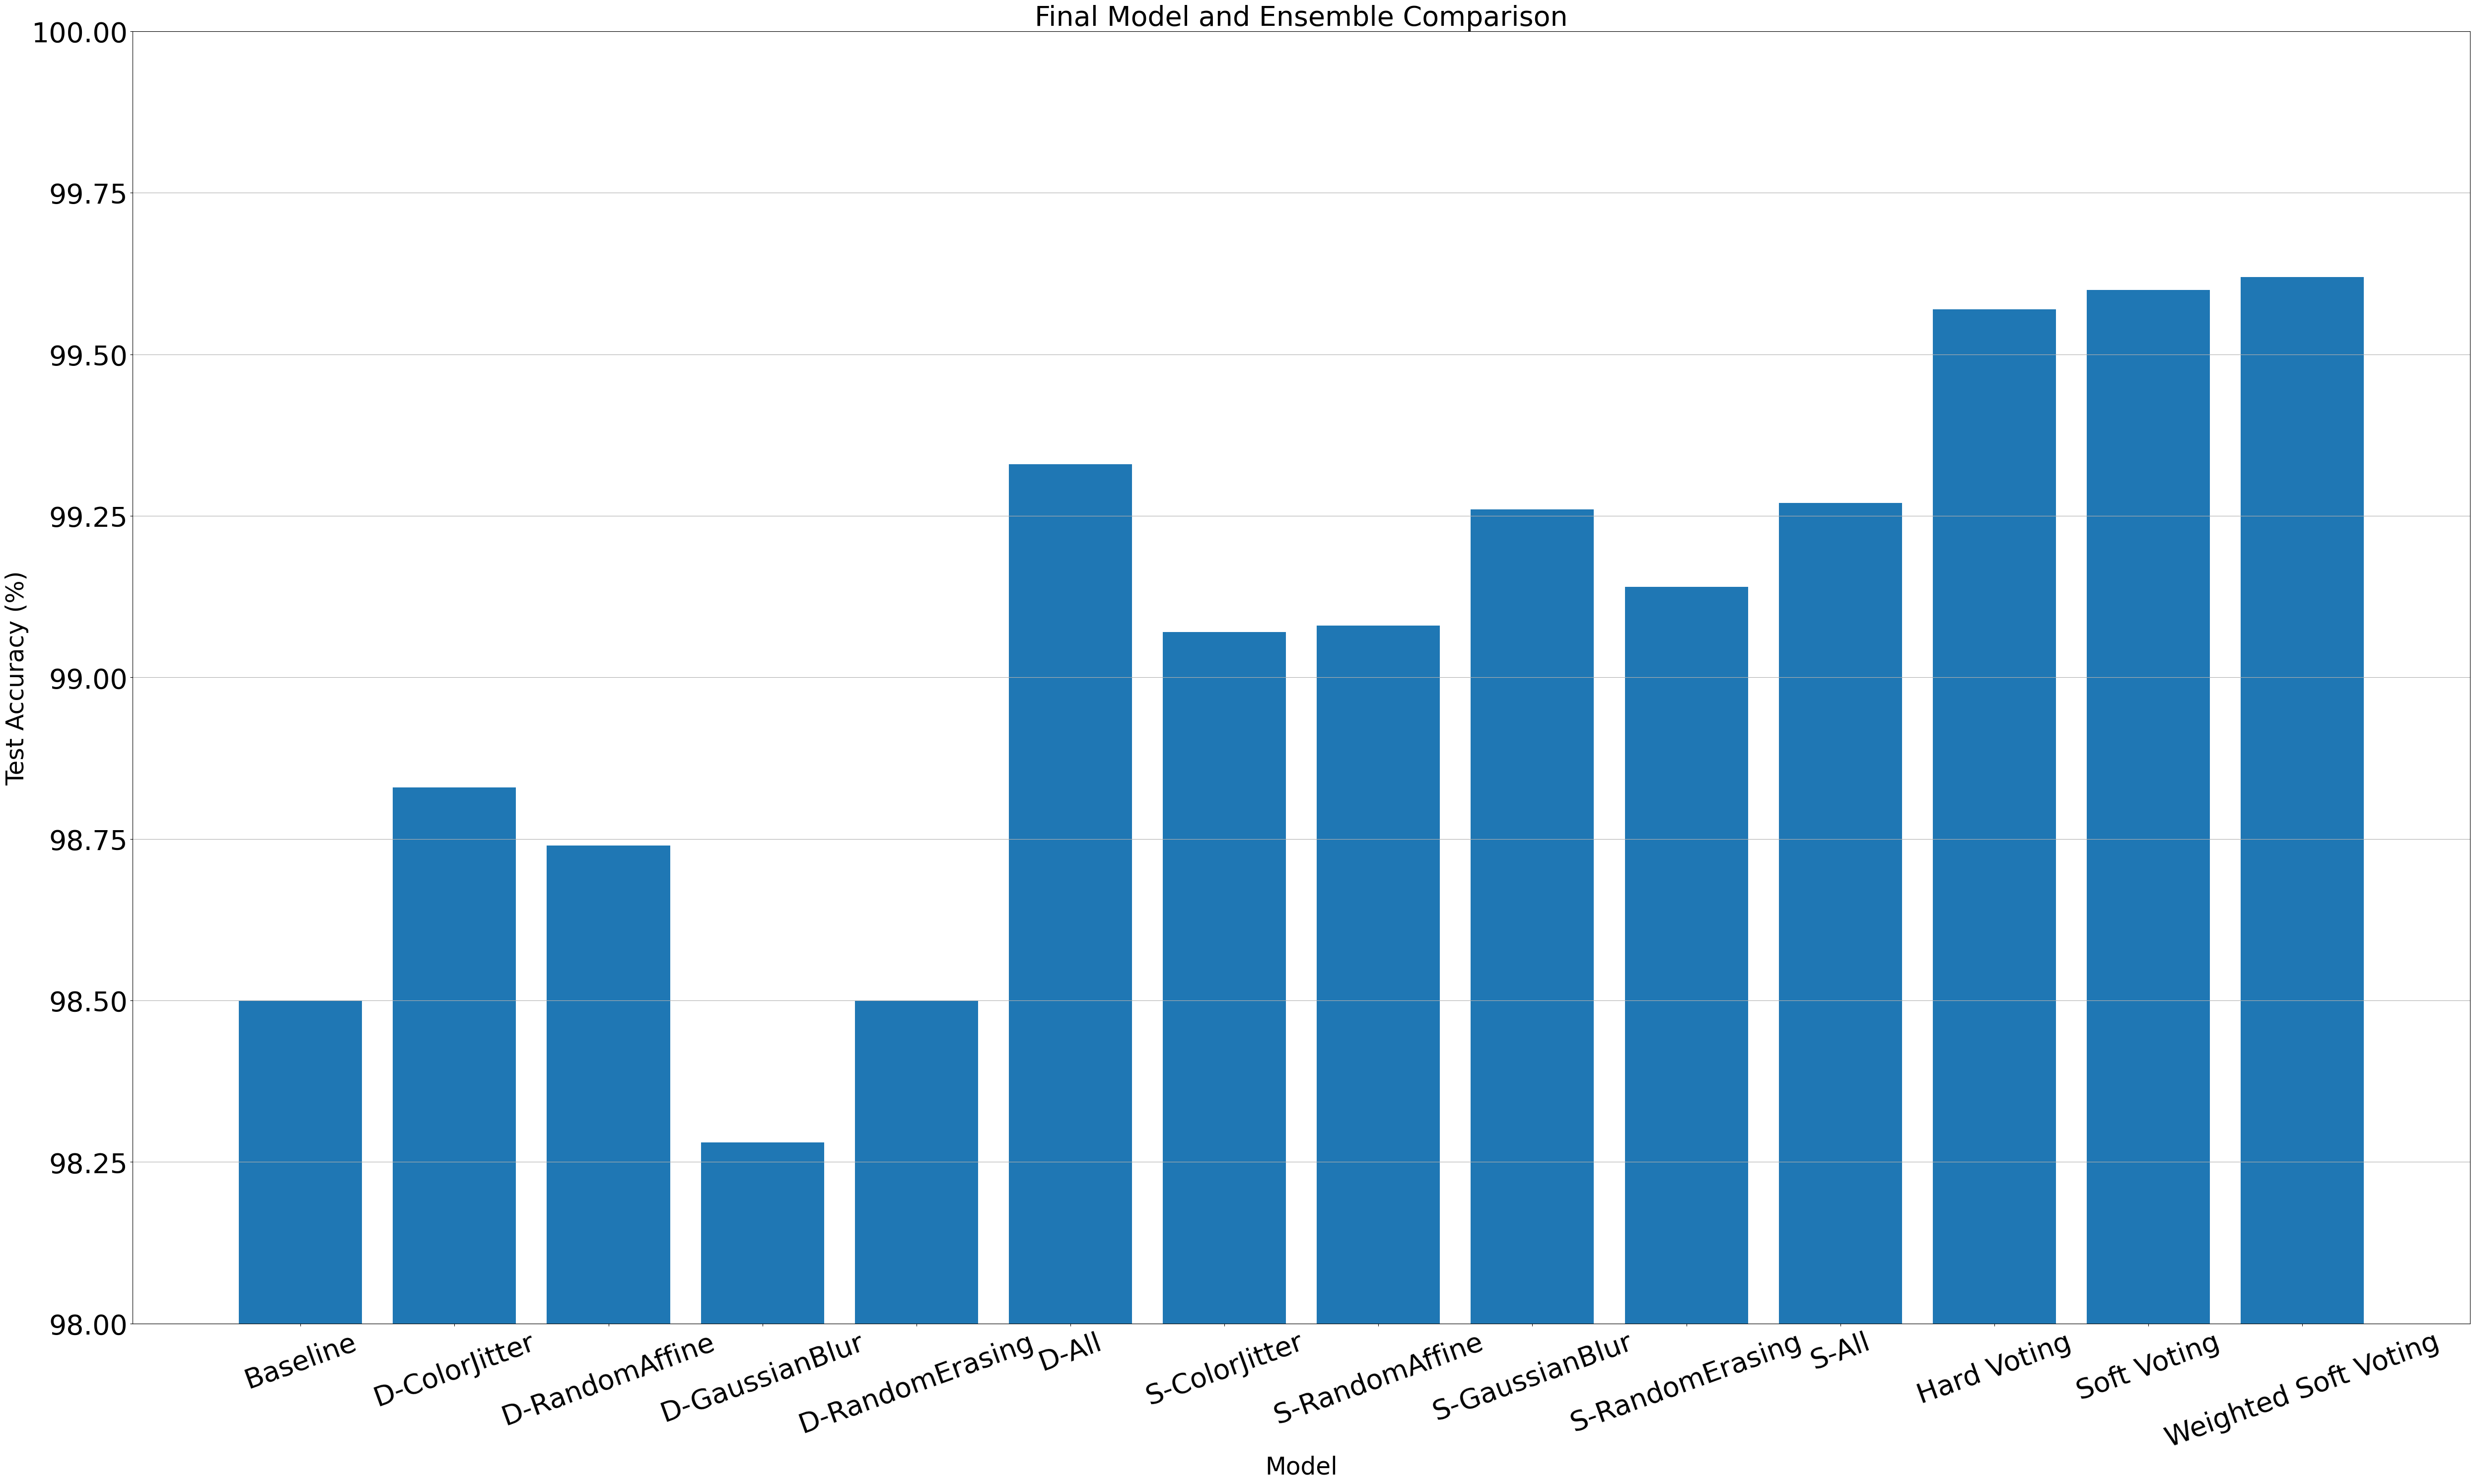

In [96]:
models = [
    'Baseline',
    'D-ColorJitter',
    'D-RandomAffine',
    'D-GaussianBlur',
    'D-RandomErasing',
    'D-All',
    'S-ColorJitter',
    'S-RandomAffine',
    'S-GaussianBlur',
    'S-RandomErasing',
    'S-All',
    'Hard Voting',
    'Soft Voting',
    'Weighted Soft Voting'
]

test_acc = [
    98.50,
    98.83,
    98.74,
    98.28,
    98.50,
    99.33,
    99.07,
    99.08,
    99.26,
    99.14,
    99.27,
    99.57,
    99.60,
    99.62
]

plt.figure(figsize=(50,30))
plt.bar(models, test_acc)

plt.ylabel('Test Accuracy (%)', fontsize=35)
plt.xlabel('Model', fontsize=35)

plt.ylim(98, 100)
plt.grid(axis='y')

plt.xticks(rotation=20, fontsize=40)
plt.yticks(fontsize=40)

plt.title('Final Model and Ensemble Comparison', fontsize=40)

plt.tight_layout()
plt.show()